# Plotting correlation functions

Here, we plot correlation functions, integration kernels etc

## 1 Preliminaries <a id='preliminaries'></a>
### 1.1 Packages <a id='packages'></a>
[Back to content](#content)

In [22]:
# Load packages, including CAMB
%matplotlib inline
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
# Use TeX
from matplotlib import rc

from scipy.stats import gaussian_kde

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

# Path to save figures
path = "/Users/pierrefleury/Nextcloud/Research projects/ELROND/article - Cosmology/figures/" # Pierre
# path = 'Figures/' # Daniel

## 1.2 Importing local modules

In [2]:
from config import *                                #all constants, defined in the config.py file

from functions.useful_functions import *            #useful functions, defined in the functions/useful_functions.py file
from functions.angular_distributions import *

## 1.3 loading correlations and distributions

In [3]:
load_correlations(filename="correlations_NE=6_NP=6")

nTheta = 100000

In [4]:
#reading in the forecasted sample of Euclid lenses
Euclid_lenses = np.loadtxt('lenses_Euclid.txt')
zd = Euclid_lenses[:, 0]
zs = Euclid_lenses[:, 1]

# convert into comoving distances (in Mpc)
chid = background.comoving_radial_distance(zd)
chis = background.comoving_radial_distance(zs)

chimax_L = max(chis)

chimax_E = background.comoving_radial_distance(zmax_E)
chimax_P = background.comoving_radial_distance(zmax_P)

chimax = max(chimax_L,chimax_E,chimax_P) 

#place these variables in the global dictionary
add_dict(chimax, chid, chis, zd, zs)

Plot lens distribution

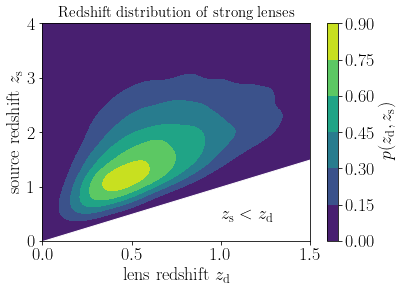

In [5]:
# Create a grid for evaluation
xmin, xmax = 0, 1.5
ymin, ymax = 0, 4
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([zd, zs])

# Compute the kernel density estimate
kernel = gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)

# Plot the PDF
#plt.figure(figsize=(6, 4))
plt.contourf(xx, yy, f, cmap='viridis')
plt.colorbar(label=r'$p(z_{\rm d}, z_{\rm s})$')

# Fill the area zd > zs in white
plt.fill_between([xmin, xmax], [xmin, xmax], ymin, color='white', alpha=1)
plt.text(1, 0.4, r"$z_{\rm s}<z_{\rm d}$", color='black')


plt.xlabel(r'lens redshift $z_{\rm d}$')
plt.ylabel(r'source redshift $z_{\rm s}$')
plt.title('Redshift distribution of strong lenses', fontsize='small')
#plt.savefig(path+'redshift_distribution_SL.pdf', bbox_inches='tight')
plt.show()

Plot galaxy distribution

In [6]:
Nbinz = 6
Nbinz_E = Nbinz 
Nbinz_P = Nbinz 
folder_name = f"Nlens=1e5_sigL=0.05_Nbin_z={Nbinz}_SNR_goal=8_Nbin_max=20_nsamp=1e6"
redshift_distributions = load_file(f"data/{folder_name}/redshift_distributions")

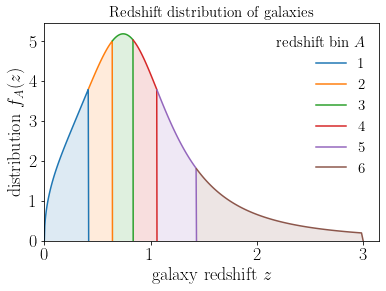

In [7]:
bin_limits = redshift_distributions['P'].limits

for A in range(Nbinz):
    
    zmin, zmax = bin_limits[A], bin_limits[A+1] 
    z = np.linspace(zmin, zmax, 100)
    p = [redshift_distributions['P'].pb(z_, A) for z_ in z]
    
    plt.plot(z, p, label=A+1)
    plt.fill_between(z, 0, p, alpha=0.15)
    
plt.xlim(xmin=0)
plt.ylim(ymin=0)

plt.legend(
    title=r'redshift bin $A$',
    alignment='right',
    fontsize='small',
    title_fontsize='small',
    frameon=False)

plt.xlabel(r'galaxy redshift $z$')
plt.ylabel(r'distribution $f_A(z)$')
plt.title(r'Redshift distribution of galaxies', fontsize="small")

#plt.savefig(path+'redshift_distribution_galaxies.pdf', bbox_inches='tight')
plt.show()

In [8]:
sigma2_shape_noise_KiDS = np.array([0.146, 0.133, 0.149, 0.129, 0.145])
np.sqrt(sigma2_shape_noise_KiDS/2)

array([0.27018512, 0.25787594, 0.27294688, 0.2539685 , 0.26925824])

## 2. Correlation functions

### 2.1 Autocorrelations

#### 2.1.1 LL

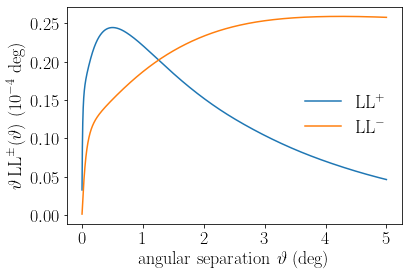

In [9]:
get_item('LL_plus', 'LL_minus')
get_item('LLp', 'LLx')

Thetamax_arcmin = 300

Thetamin = arcmintorad(Thetamin_arcmin)
Thetamax = arcmintorad(Thetamax_arcmin)

logThetamin = np.log10(Thetamin)
logThetamax = np.log10(Thetamax)
Theta = np.logspace(logThetamin, logThetamax, nTheta)

Theta_deg =  Theta * 180/np.pi

LL_plus_plot = LL_plus(Theta)
LL_minus_plot = LL_minus(Theta)

#not currently used, but available for plotting
LLp_plot = LLp(Theta)
LLx_plot = LLx(Theta)

# # Plus correlations
plt.plot(Theta_deg,
         Theta_deg * LL_plus_plot * 1e4, color='tab:blue', linestyle='-',
         label=r'${\rm LL^+}$')
# Minus correlations
plt.plot(Theta_deg,
         Theta_deg * LL_minus_plot * 1e4, color='tab:orange', linestyle='-',
         label=r'${\rm LL^-}$')

plt.xlabel(r'angular separation $\vartheta$ (deg)')
plt.ylabel(r'$\vartheta\,{\rm LL^\pm(\vartheta)}$ ($10^{-4}$ deg)')
plt.legend(frameon=False)
plt.show()

#### 2.1.2 EE

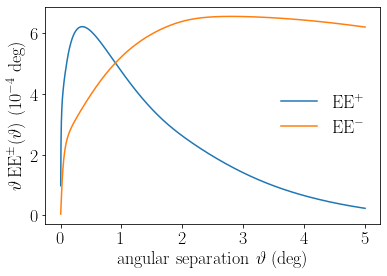

In [10]:
b1 = 5
b2 = 5

Thetamax_arcmin = 300

Thetamin = arcmintorad(Thetamin_arcmin)
Thetamax = arcmintorad(Thetamax_arcmin)

logThetamin = np.log10(Thetamin)
logThetamax = np.log10(Thetamax)
Theta = np.logspace(logThetamin, logThetamax, nTheta)

Theta_deg =  Theta * 180/np.pi
get_item('EE_plus', 'EE_minus')

EE_plus_plot = EE_plus[b1][b2](Theta)*36
EE_minus_plot = EE_minus[b1][b2](Theta)*36

# Plus correlations
plt.plot(Theta_deg,
         Theta_deg * EE_plus_plot * 1e4, color='tab:blue', linestyle='-',
         label=r'${\rm EE^+}$')
# Minus correlations
plt.plot(Theta_deg,
         Theta_deg * EE_minus_plot * 1e4, color='tab:orange', linestyle='-',
         label=r'${\rm EE^-}$')

plt.xlabel(r'angular separation $\vartheta$ (deg)')
plt.ylabel(r'$\vartheta \, {\rm EE^\pm}(\vartheta)$ ($10^{-4}$ deg)')
plt.legend(frameon=False)
plt.show()

#### 2.1.3 PP

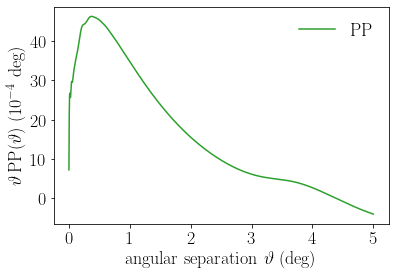

In [11]:
b1 = 1
b2 = 1

get_item('PP')


Thetamax_arcmin = 300

Thetamin = arcmintorad(Thetamin_arcmin)
Thetamax = arcmintorad(Thetamax_arcmin)

logThetamin = np.log10(Thetamin)
logThetamax = np.log10(Thetamax)
Theta = np.logspace(logThetamin, logThetamax, nTheta)

Theta_deg =  Theta * 180/np.pi

PP_plot = PP[b1][b2](Theta)

# correlations
plt.plot(Theta_deg,
         Theta_deg * PP_plot * 1e4, color='tab:green', linestyle='-',
         label=r'${\rm PP}$')

plt.xlabel(r'angular separation $\vartheta$ (deg)')
plt.ylabel(r'$\vartheta \, {\rm PP}(\vartheta)$ ($10^{-4}$ deg)')
plt.legend(frameon=False)
plt.show()

## 2.2 Cross-correlation functions

#### 2.2.1 LE

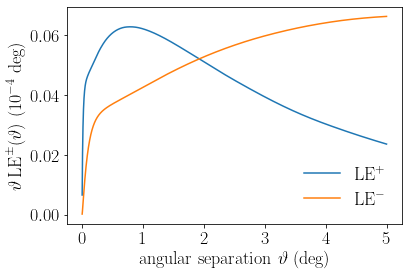

In [12]:
b1 = 1
get_item('LE_plus', 'LE_minus')

LE_plus_plot = LE_plus[b1](Theta)
LE_minus_plot = LE_minus[b1](Theta)

# Plus correlations
plt.plot(Theta_deg,
         Theta_deg * LE_plus_plot * 1e4, color='tab:blue', linestyle='-',
         label=r'${\rm LE^+}$')
# Minus correlations
plt.plot(Theta_deg,
         Theta_deg * LE_minus_plot * 1e4, color='tab:orange', linestyle='-',
         label=r'${\rm LE^-}$')

plt.xlabel(r'angular separation $\vartheta$ (deg)')
plt.ylabel(r'$\vartheta \, {\rm LE}^\pm(\vartheta)$ ($10^{-4}$ deg)')
plt.legend(frameon=False)
plt.show()

#### 2.2.2 LP

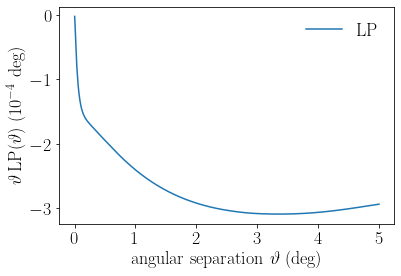

In [13]:
b1 = 0

get_item('LP')

LP_plot = LP[b1](Theta)

# correlations
plt.plot(Theta_deg,
         Theta_deg * LP_plot * 1e4, color='tab:blue', linestyle='-',
         label=r'${\rm LP}$')
plt.xlabel(r'angular separation $\vartheta$ (deg)')
plt.ylabel(r'$\vartheta \, {\rm LP}(\vartheta)$ ($10^{-4}$ deg)')
plt.legend(frameon=False)
plt.show()

#### 2.2.3 EP

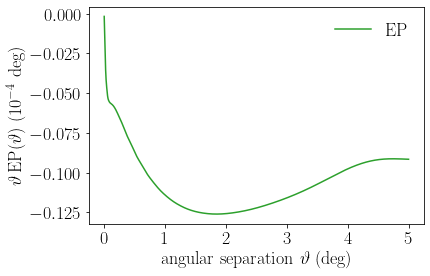

In [14]:
b1 = 1
b2 = 1

get_item('EP')

EP_plot = EP[b1][b2](Theta)

# correlations
plt.plot(Theta_deg,
         Theta_deg * EP_plot * 1e4, color='tab:green', linestyle='-',
         label=r'${\rm EP}$')
plt.xlabel(r'angular separation $\vartheta$ (deg)')
plt.ylabel(r'$\vartheta \, {\rm EP}(\vartheta)$ ($10^{-4}$ deg)')
plt.legend(frameon=False)
plt.show()

## 3. Plotting integrated correlation functions (testing optimised binscheme)

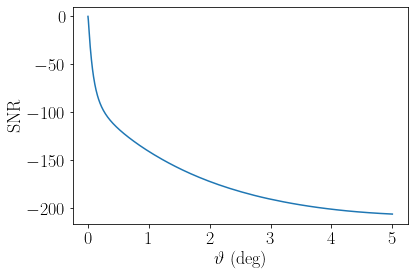

In [15]:
def integral_bins(correlation_function, Theta_start, Theta_end):

    integrand = lambda x: x*correlation_function(x)
    
    integral, err = quad(integrand, Theta_start, Theta_end)

    return integral

def SNR(integrand, theta):
    
    Omega = np.pi * theta **2 

    integral = integral_bins(integrand, 0, theta)

    return integral/np.sqrt(Omega)

Thetamax_arcmin = 300

Thetamin = arcmintorad(Thetamin_arcmin)
Thetamax = arcmintorad(Thetamax_arcmin)

logThetamin = np.log10(Thetamin)
logThetamax = np.log10(Thetamax)
Theta = np.logspace(logThetamin, logThetamax, 200)

Theta_deg = Theta * 180/np.pi

snr = []

for theta_val in Theta:
    s = SNR(LP[0], theta_val)
    snr.append(s*np.sqrt(2*(1e5)*NGal/( 6*(0.05)**2 * sky_coverage * (np.pi/180)**2 )))

plt.plot(Theta_deg,snr)
plt.ylabel(r'SNR')
plt.xlabel(r'$\vartheta$ (deg)');

## 3. Average kernel plots

In [16]:
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import astropy.units as u

def z(chi):
    return z_at_value(cosmo.comoving_distance, chi * u.Mpc)

# CAMB parameters
H0=67.37       #Hubble constant
ombh2=0.0223   #baryon density parameter
omch2=0.1198   #dark matter density parameter

pars = camb.CAMBparams()                              #initialise the CAMBparams object, which contains all cosmological parameters and settings
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2)   #define the cosmological model
pars.InitPower.set_params(ns=ns)                      #set the primordial power spectrum parameters
results = camb.get_background(pars)                #compute the background cosmological evolution

Nbinz = 6
Nbinz_E = Nbinz 
Nbinz_P = Nbinz 
folder_name = f"Nlens=1e5_sigL=0.05_Nbin_z={Nbinz}_SNR_goal=8_Nbin_max=20_nsamp=1e6"
redshift_distributions = load_file(f"data/{folder_name}/redshift_distributions")

### 3.1 The LOS shear

In [17]:
#this is the same as KLOS, but with an added factor of chi
chimin=1e-5

def K_LOS(chi, chidd, chiss):
    """
    LOS weight function

    chi : an inputted value of comoving distance
    chidd : the comoving distance to the lens
    chiss : the comoving distance to the source
    """
        
    os = (chiss - chi) / chiss #the weight function for gamma_os
    od = (chidd - chi) / chidd #the weight function for gamma_od
    ds = (chi - chidd) * (chis - chi) / (chi * (chiss - chidd) ) #the weight function for gamma_ds

    #the actual weight function
    K  = (os * np.heaviside(os, 0)    #returns 0 if os is negative
          + od * np.heaviside(od, 0)
          - ds * np.heaviside(ds, 0))
    
    return K

def K_LOS_mean(chi):
    """
    Redshift-averaged LOS weight function
    
    chi : an inputted comoving distance
    """
    K = np.mean(K_LOS(chi, chid, chis))
    
    return K

def Q_LOS_mean(chi):
    """
    Redshift-averaged LOS integration kernel
    
    chi : an inputted comoving distance
    """
    redshift = background.redshift_at_comoving_radial_distance(chi)
    
    Q = 1.5 * Omega_M * (H0/(c*1e-3))**2 * (1+redshift) * K_LOS_mean(chi)
    
    return Q

# Interpolate to get a fast 1D weight function
Q_LOS_mean_vec = np.vectorize(Q_LOS_mean)
chi = np.linspace(chimin, chimax, 1000)
Q = Q_LOS_mean_vec(chi)
Q_LOS_mean_intp = CubicSpline(chi, Q) 
    
nz = 1000 #number of elements for discrete integral along the los
    
# Conformal distances and redshifts
chivals = np.linspace(chimin, chimax, nz) #dimension chi
zs = results.redshift_at_comoving_radial_distance(chivals) #dimension redshift
    
# Array of delta_chi, and drop first and last points where things go singular
dchivals = (chivals[2:]-chivals[:-2])/2
chivals = chivals[1:-1]
zs = zs[1:-1]

# Lensing kernel (here LOS shear)
QL = Q_LOS_mean_intp(chivals)

chivalsQL = chivals

### 3.2 The weak lensing shear

In [18]:
def K_os(chi, chiss):
    """
    weak lensing weight function, which tells us the relative contribution of matter
    at chi to the weak lensing of a source at chis

    chi : an inputted value of comoving distance
    chiss : the comoving distance to the source
    """

    os = (chiss - chi) / chiss #the weight function for gamma_os

    #the actual weight function
    K  = os * np.heaviside(os, 0)    #returns 0 if os is negative
    
    return K

def K_os_mean(chi, b):
    """
    Redshift-averaged os integration kernel

    chi : an inputted comoving distance
    b   : the redshift bin in question
    """
    
    z_min = redshift_distributions['E'].limits[b]                                  #the minimum redshift of a source
    z_max = redshift_distributions['E'].limits[b+1]                                #the maximum redshift of a source

    #this integrand returns the probability of a source being at redshift z_source
    def integrand(z_source):
    
        p_b = redshift_distributions['E'].pb(z_source, b)                     #the probability associated with a source being at z_source (in redshift bin b)
        chi_source = background.comoving_radial_distance(z_source)            #the comoving distance to the source at z_source
        
        return p_b * K_os(chi,chi_source) 

    #we integrate our weighting function over all the source positions in the relevant bin
    K, err = integrate.quad(integrand, z_min, z_max)
    
    return K

def Q_os_mean(chi,b):
    """
    os integration kernel

    chi : an inputted value of comoving distance
    chiss : the comoving distance to the source
    """
    redshift = background.redshift_at_comoving_radial_distance(chi)
    
    Q = 1.5 * Omega_M * (H0/(c*1e-3))**2 * (1+redshift) * K_os_mean(chi,b)
    
    return Q
    
# Interpolate to get fast 1D weight functions

Q_os_mean_intp = []

for b in range(Nbinz_E):
    Q_os_mean_vec = np.vectorize(Q_os_mean)
    chi = np.linspace(chimin, chimax, 1000)
    Q = Q_os_mean_vec(chi, b)
    Q_os_mean_intp.append(CubicSpline(chi, Q))

nz = 1000 #number of elements for discrete integral along the los
    
# Conformal distances and redshifts
chivals = np.linspace(chimin, chimax, nz)
zs = results.redshift_at_comoving_radial_distance(chivals)

# Array of delta_chi, and drop first and last points where things go singular
dchivals = (chivals[2:]-chivals[:-2])/2
chivals = chivals[1:-1]
zs = zs[1:-1]

QE = []

for b in range(Nbinz_E):
    # Lensing kernel (here weak lensing shear)    
    QE.append(Q_os_mean_intp[b](chivals))
    
chivalsQE = chivals

### 3.3 Galaxy positions

In [19]:
def bias(z):
    return 1.1*z**2.4/(1+z)+0.9

#the "weight function" (the equivalent of W_mean in os and LOS)
def Q_d(chi, b):

    redshift = background.redshift_at_comoving_radial_distance(chi)

    H = H0 * np.sqrt(Omega_M*(1+redshift)**3+Omega_L) / (c*1e-3)
    
    return redshift_distributions['P'].pb(redshift, b) * H * bias(redshift) / chi  

print(H0 * np.sqrt(Omega_M*(1)**3+Omega_L)/ (c*1e-3) )
print(c*1e-3)

Q_d_mean_intp = []

for b in range(Nbinz_P):
    Q_d_mean_vec = np.vectorize(Q_d)
    chii = np.linspace(chimin, chimax, 1000)
    Q = Q_d_mean_vec(chii, b)
    Q_d_mean_intp.append(CubicSpline(chii, Q))

# Interpolate to get fast 1D weight functions

Q_d_intp = Q_d_mean_intp  #redundant, fix this

nz = 1000 #number of elements for discrete integral along the los

# Conformal distances and redshifts
chivals = np.linspace(chimin, chimax, nz)
zs = results.redshift_at_comoving_radial_distance(chivals)

# Array of delta_z, and drop first and last points where things go singular
dchivals = (chivals[2:]-chivals[:-2])/2
chivals = chivals[1:-1]
zs = zs[1:-1]

# Everything in the integrand except Weyl power spectrum

QP = []

for b in range(Nbinz_P):

    QP.append(Q_d_intp[b](chivals))

chivalsQP = chivals

0.00022456666666666669
300000.0


### 3.4 plotting

FileNotFoundError: [Errno 2] No such file or directory: 'Figures/kernels.pdf'

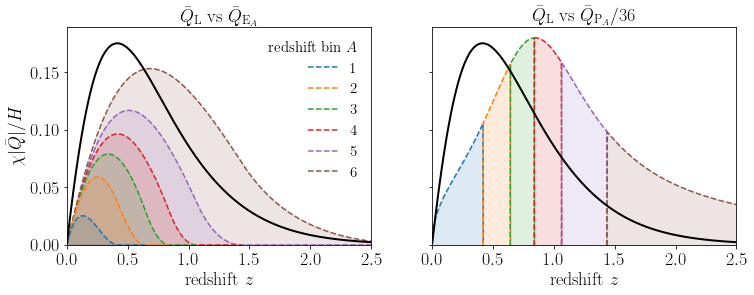

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True, constrained_layout=False)

H = H0 * np.sqrt(Omega_M*(1+z(chivals))**3+Omega_L) / (c*1e-3)

cmap = plt.get_cmap('tab10')


#QL + QE on the left
axL = axes[0]

for b in range(Nbinz_E):
    b = (Nbinz_E - 1) - b # reverse order
    if b < Nbinz_E - 2:
        mask = QE[b+1] > 0
    else:
        mask = np.ones_like(QE[b], dtype=bool)
    color = cmap(b)
    x= z(chivalsQE[mask])
    y= H[mask]**(-1)*QE[b][mask]* chivalsQE[mask]
    axL.plot(x, y, '--', color = color, label=b+1) #
    axL.fill_between(x, 0, y, color=color, alpha=0.15)
    
mask = QL > 0
axL.plot(z(chivalsQL[mask]), H[mask]**(-1)*QL[mask] * chivalsQL[mask], 'k-', linewidth=2) #

axL.set_xlim(0, 2.5)
axL.set_ylabel(r'$\chi |\bar{Q}|/H$')
axL.set_xlabel('redshift $z$')
axL.set_title(r'$\bar{Q}_\mathrm{L}$ vs $\bar{Q}_{\mathrm{E}_A}$',
             fontsize='medium')

#QL + QP on the right
axR = axes[1]

def padded_mask(arr, pad=2):
    nonzero = arr > 0
    if not np.any(nonzero):
        return np.zeros_like(arr, dtype=bool)

    # indices of first and last nonzero location
    i_min = np.argmax(nonzero)
    i_max = len(arr) - np.argmax(nonzero[::-1]) - 1

    # apply padding
    i_min = max(i_min - pad, 0)
    i_max = min(i_max + pad, len(arr) - 1)

    mask = np.zeros_like(arr, dtype=bool)
    mask[i_min:i_max+1] = True
    return mask

for b in range(Nbinz_P):
    mask = padded_mask(QP[b], pad=2)
    x = z(chivalsQP[mask])
    y = H[mask]**(-1)*QP[b][mask]*chivalsQP[mask]*1/36
    color = cmap(b)
    axR.plot(x, y, '--', color=color) # 
    axR.fill_between(x, 0, y, color=color, alpha=0.15)
    
mask = QL > 0
axR.plot(z(chivalsQL[mask]), H[mask]**(-1)*QL[mask]* chivalsQL[mask] , 'k-', linewidth=2) #

axR.set_xlim(0, 2.5)
axR.set_ylim(ymin=0)
axR.set_xlabel('redshift $z$')
axR.set_title(r'$\bar{Q}_\mathrm{L}$ vs $\bar{Q}_{\mathrm{P}_A}/36$',
              fontsize='medium')

# legend on left panel

handles, labels = axL.get_legend_handles_labels()
# invert order
handles = handles[::-1]
labels = labels[::-1]

axL.legend(
    handles, labels,
    title=r'redshift bin $A$',
    alignment='right',
    fontsize='small',
    title_fontsize='small',
    frameon=False)

plt.savefig(path+'kernels.pdf', bbox_inches='tight')
plt.show()